# Counterfeit detection — solution

This notebook solves parts (A–D) of the Gaussian Mixture Discriminant analysis tasks

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Data loading

In [67]:
data = pd.read_csv('data/banknote_authentication.csv')
print(data.shape)
print(data['counterfeit'].value_counts())
data.head()

(1097, 4)
counterfeit
0    609
1    488
Name: count, dtype: int64


,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


In [68]:
features = ['a1', 'a2', 'a3']
X = data[features].values
y = data['counterfeit'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pi1_train = y_train.mean()  # empirical class prior
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Prior P(counterfeit) in train: {pi1_train}")

Train: (877, 3), Test: (220, 3)
Prior P(counterfeit) in train: 0.44469783352337516


---
## A. Quadratic Discriminant Analysis

QDA fits a separate multivariate Gaussian for each class and uses the resulting
posteriors for classification. Unlike LDA each class to have it is own
covariance matrix.

In [69]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

qda_proba = qda.predict_proba(X_test)[:, 1]
qda_pred  = qda.predict(X_test)

cm_qda  = confusion_matrix(y_test, qda_pred)
auc_qda = roc_auc_score(y_test, qda_proba)
fpr_qda, tpr_qda, thd_qda = roc_curve(y_test, qda_proba)

print("Confusion Matrix (QDA):")
print(cm_qda)
print(f"AUC: {auc_qda}")

Confusion Matrix (QDA):
[[93 29]
 [14 84]]
AUC: 0.8606557377049181


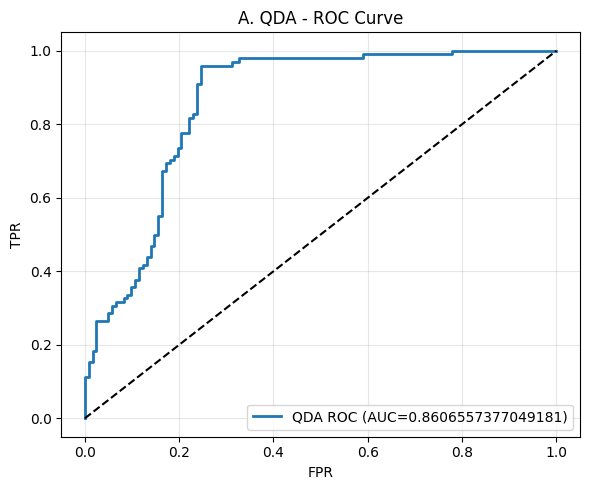

In [70]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_qda, tpr_qda, lw=2, label=f'QDA ROC (AUC={auc_qda})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('A. QDA - ROC Curve'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## B. Gaussian Mixture Discriminant analysis

Instead of a single Gaussian per class, we fit a GMM using the EM algorithm.


In [71]:
def fit_gmda(X_train, y_train, n0, n1):
    gm0 = GaussianMixture(n_components=n0, covariance_type='full',
                          random_state=42, max_iter=300)
    gm1 = GaussianMixture(n_components=n1, covariance_type='full',
                          random_state=42, max_iter=300)
    gm0.fit(X_train[y_train == 0])
    gm1.fit(X_train[y_train == 1])
    return gm0, gm1

def gmda_predict_proba(gm0, gm1, X, pi1=0.5):
    log_l0 = gm0.score_samples(X)
    log_l1 = gm1.score_samples(X)
    pi0 = 1 - pi1
    log_num = np.log(pi1) + log_l1
    log_den = np.log(pi0) + log_l0
    log_max = np.maximum(log_num, log_den)
    proba1  = np.exp(log_num - log_max) / (
        np.exp(log_num - log_max) + np.exp(log_den - log_max))
    return proba1

In [72]:
gm0_b, gm1_b = fit_gmda(X_train, y_train, n0=2, n1=2)

gmda_proba = gmda_predict_proba(gm0_b, gm1_b, X_test, pi1=pi1_train)
gmda_pred  = (gmda_proba >= 0.5).astype(int)

cm_gmda  = confusion_matrix(y_test, gmda_pred)
auc_gmda = roc_auc_score(y_test, gmda_proba)
fpr_gmda, tpr_gmda, thd_gmda = roc_curve(y_test, gmda_proba)

print("Confusion Matrix (GMDA 2+2):")
print(cm_gmda)
print(f"AUC: {auc_gmda}")

Confusion Matrix (GMDA 2+2):
[[116   6]
 [ 13  85]]
AUC: 0.9652057544329208


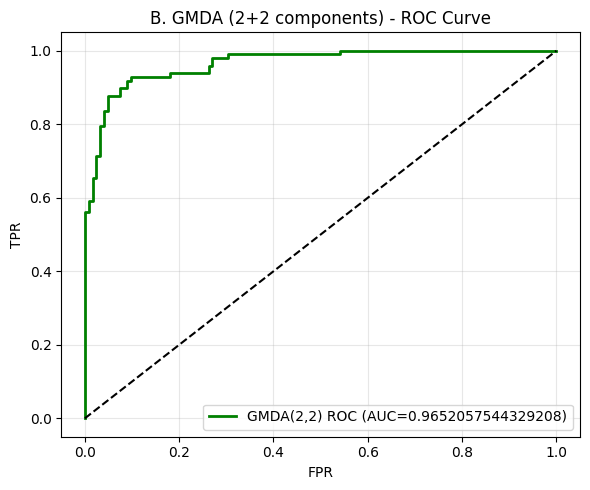

In [73]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_gmda, tpr_gmda, lw=2, color='green',
        label=f'GMDA(2,2) ROC (AUC={auc_gmda})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('B. GMDA (2+2 components) - ROC Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## C. Cross validated GMDA : Optimal number of components

We search over (n0, n1) in {1 ... 12}^2 using 5-fold stratified CV scoring by AUC.

In [74]:
def cv_gmda_auc(X, y, n0, n1, n_splits=5):
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for train_idx, val_idx in skf.split(X, y):
        Xtr, Xval = X[train_idx], X[val_idx]
        ytr, yval = y[train_idx], y[val_idx]
        pi1 = ytr.mean()
        try:
            gm0, gm1 = fit_gmda(Xtr, ytr, n0, n1)
            prob = gmda_predict_proba(gm0, gm1, Xval, pi1=pi1)
            if np.any(np.isnan(prob)):
                return -np.inf
            aucs.append(roc_auc_score(yval, prob))
        except Exception:
            return -np.inf
    return np.mean(aucs)

max_k = 12
best_auc_cv = -1
best_n0, best_n1 = 1, 1
results = {}

for n0 in range(1, max_k + 1):
    for n1 in range(1, max_k + 1):
        auc = cv_gmda_auc(X_train, y_train, n0, n1)
        results[(n0, n1)] = auc
        if auc > best_auc_cv:
            best_auc_cv = auc
            best_n0, best_n1 = n0, n1

print(f"Best: n0={best_n0}, n1={best_n1} (counterfeit), CV AUC={best_auc_cv}")

Best: n0=12, n1=7 (counterfeit), CV AUC=0.9934168433432056


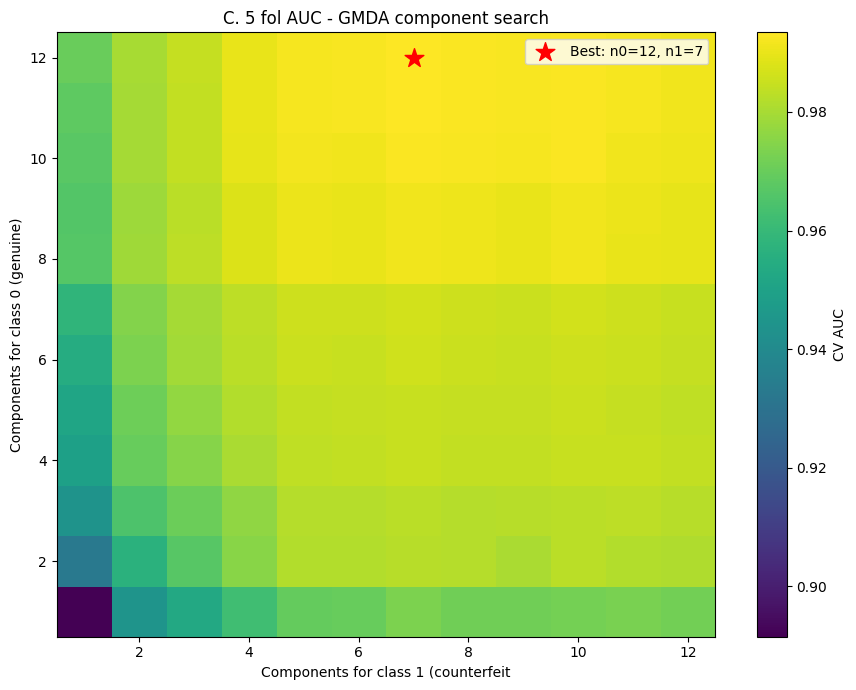

In [75]:

auc_matrix = np.array([[results.get((n0,n1),0) for n1 in range(1,max_k+1)]
                        for n0 in range(1,max_k+1)])

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(auc_matrix, aspect='auto', origin='lower',
               extent=[0.5, max_k+0.5, 0.5, max_k+0.5],
               cmap='viridis', vmin=auc_matrix[auc_matrix>0].min())
plt.colorbar(im, ax=ax, label='CV AUC')
ax.scatter(best_n1, best_n0, s=200, color='red', marker='*', zorder=5,
           label=f'Best: n0={best_n0}, n1={best_n1}')
ax.set_xlabel('Components for class 1 (counterfeit')
ax.set_ylabel('Components for class 0 (genuine)')
ax.set_title('C. 5 fol AUC - GMDA component search')
ax.legend(); plt.tight_layout(); plt.show()

In [76]:

gm0_c, gm1_c = fit_gmda(X_train, y_train, best_n0, best_n1)
best_proba = gmda_predict_proba(gm0_c, gm1_c, X_test, pi1=pi1_train)
best_pred  = (best_proba >= 0.5).astype(int)

cm_best  = confusion_matrix(y_test, best_pred)
auc_best = roc_auc_score(y_test, best_proba)
fpr_best, tpr_best, thd_best = roc_curve(y_test, best_proba)

print(f"Best GMDA ({best_n0}+{best_n1}) Confusion Matrix:")
print(cm_best)
print(f"test AUC: {auc_best}")

Best GMDA (12+7) Confusion Matrix:
[[119   3]
 [  4  94]]
test AUC: 0.9966543994647039


---
## D. Optimal decision threshold under cost

Problem:
- Prior probability of a counterfeit bill:  0.01 p_c
- Loss for accepting a counterfeit :  100 PLN L_fn
- Loss for rejecting a genuine bill: 15 PLN L_fp

Expected loss per transaction as a function of the threshold

We minimise L(t) over all operating points on the ROC curve.

In [77]:
p_c  = 0.01
p_g  = 0.99
L_fn = 100.0
L_fp = 15.0

def expected_loss(fpr_arr, tpr_arr):
    return p_c * (1 - tpr_arr) * L_fn + p_g * fpr_arr * L_fp

def optimal_threshold(fpr_arr, tpr_arr, thd_arr, label):
    loss = expected_loss(fpr_arr, tpr_arr)
    idx  = np.argmin(loss)
    print(f"{label}:")
    print(f"Optimal threshold: {thd_arr[idx]}")
    print(f"FPR / TPR: {fpr_arr[idx]} / {tpr_arr[idx]}")
    print(f"Expected loss: {loss[idx]} PLN/customer")
    return idx, loss[idx]

idx_qda,  loss_qda  = optimal_threshold(fpr_qda,  tpr_qda,  thd_qda,  "A. QDA")
print()
idx_gmda, loss_gmda = optimal_threshold(fpr_gmda, tpr_gmda, thd_gmda, "B. GMDA(2,2)")
print()
idx_best, loss_best = optimal_threshold(fpr_best, tpr_best, thd_best,
                                         f"C. Best GMDA({best_n0},{best_n1})")

A. QDA:
Optimal threshold: 0.9927309098665918
FPR / TPR: 0.0 / 0.11224489795918367
Expected loss: 0.8877551020408164 PLN/customer

B. GMDA(2,2):
Optimal threshold: 0.9301980726495447
FPR / TPR: 0.0 / 0.5612244897959183
Expected loss: 0.4387755102040817 PLN/customer

C. Best GMDA(12,7):
Optimal threshold: 0.8059619360530761
FPR / TPR: 0.0 / 0.9387755102040817
Expected loss: 0.061224489795918324 PLN/customer


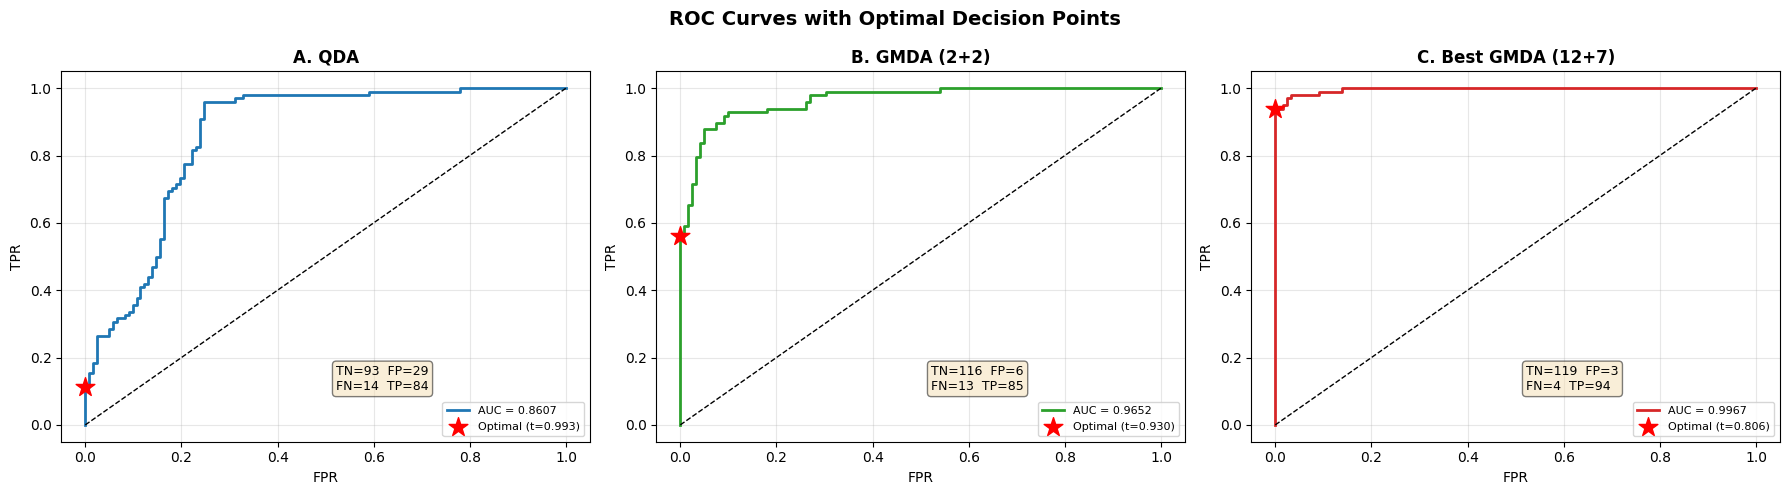

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves with Optimal Decision Points', fontsize=14, fontweight='bold')

configs = [
    (axes[0], fpr_qda,  tpr_qda,  auc_qda,  thd_qda,  idx_qda,  cm_qda,
     'A. QDA', '#1f77b4'),
    (axes[1], fpr_gmda, tpr_gmda, auc_gmda, thd_gmda, idx_gmda, cm_gmda,
     'B. GMDA (2+2)', '#2ca02c'),
    (axes[2], fpr_best, tpr_best, auc_best, thd_best, idx_best, cm_best,
     f'C. Best GMDA ({best_n0}+{best_n1})', '#d62728'),
]

for ax, fpr, tpr, auc_v, thd, opt_i, cm, title, color in configs:
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_v:.4f}')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.scatter(fpr[opt_i], tpr[opt_i], s=200, color='red', zorder=5,
               marker='*', label=f'Optimal (t={thd[opt_i]:.3f})')
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.52, 0.14, f'TN={tn}  FP={fp}\nFN={fn}  TP={tp}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Summary

The cost model heavily penalises accepting counterfeits (100 PLN) relative to
rejecting genuine bills (15 PLN), but the very low prior 1% means a  threshold
is not much pushed toward zero. the optimal point balances these two effects.
The best GMDA model achieved the lowest expected loss thanks to its superior calibration.